<a href="https://colab.research.google.com/github/purduelamm/purdue_me597_iiot/blob/main/lab/lab6/L6_Colab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 6.2 Database & Visualization - Python MySQL Hands-on Activities

## 2.1 Python Programming Using PyMySQL


The example sample code ([lab6_sample.py](https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/lab6/lab6_sample.py?raw=true)) is on Github repo and as below. This example is generating 3 random values and then executing INSERT statements to store the values on the MySQL database. The sampling period is 3 seconds and total collection time is 60 seconds. Please go through the code and comments on each line to understand program logic. Please note that you need to modify the 'USER', 'PASSWORD', and 'TABLE' lines to run the sample script.

---

**<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/icon_Python.png?raw=tru" width="20">Python - Python3 ([lab6_sample.py](https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/lab6/lab6_sample.py?raw=true))**

```
import datetime
import time
import random
import pymysql.cursors

## Credential
HOST = 'mepotrb16.ecn.purdue.edu' # MySQL server host DNS
PORT = 3306 # MySQL server port number
USER = 'yourname' # MySQL account name
PASSWORD = 'password' # Password of the account
DB = 'ME597Spring24' # DB name (you should double check your database name)
TABLE = 'yourname_lab6' # table name
## Credential

sensor = 'sensor3' # sensor name
measurement1 = 'acceleration1' # measurement name 1
measurement2 = 'acceleration2' # measurement name 2
measurement3 = 'acceleration3' # measurement name 3

connection = pymysql.connect(host=HOST, user=USER, password=PASSWORD, db=DB, port=PORT) # make a connection to MySQL server
cursor = connection.cursor() # Open cursur to execute SQL query

duration = 60 # collection time in second unit
start_time = time.time() # get current time

while time.time() - start_time < duration:
    value1 = str(random.uniform(0,2)) # random value for measurement1
    value2 = str(random.uniform(-2,0)) # random value for measurement2
    value3 = str(random.uniform(9.7,9.9)) # random value for measurement3
    timestamp = datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S') # get datetime as MySQL timestamp format
    
    print(timestamp)
    print("{}={}".format(measurement1,value1)) # value1
    print("{}={}".format(measurement2,value2)) # value2
    print("{}={}".format(measurement3,value3)) # value2
    
    query1 = "INSERT INTO "+TABLE+" (timestamp,sensor,measurement,value) VALUE('"+timestamp+"','"+sensor+"','"+measurement1+"','"+value1+"');" #SQL query1 for value1
    query2 = "INSERT INTO "+TABLE+" (timestamp,sensor,measurement,value) VALUE('"+timestamp+"','"+sensor+"','"+measurement2+"','"+value2+"');" #SQL query2 for value2
    query3 = "INSERT INTO "+TABLE+" (timestamp,sensor,measurement,value) VALUE('"+timestamp+"','"+sensor+"','"+measurement3+"','"+value3+"');" #SQL query3 for value3
    
    cursor.execute(query1) # execute query 1
    cursor.execute(query2) # execute query 2
    cursor.execute(query3) # execute query 3
    connection.commit() # commit all SQL queries
    
    print("==INSERT QUERIES DONE==\n")
    
    time.sleep(3) # wait for 3 seconds

connection.close() # gently close connection
print("==Program DONE==")

```

---

After run the sample code, you can see the stored data on ‘MySQL Workbench’ on laptop as Figure 5.

<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img_S24_update/lab6_fig5.png?raw=true" width="70%">

*Figure 5 MySQL Workbench result grid after running sample script*

### Task 2.1

Run the sample code on Raspberry Pi. Capture the result grid on MySQL workbench as Figure 5 and attach it to the report.

---

Place your screenshot here.
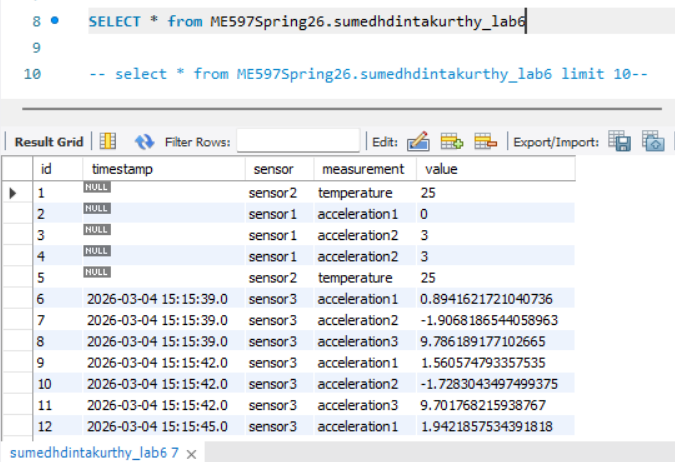
---


Now, let’s store the measured data to MySQL database from the sensors (DS18B20 and ADXL345). The schematic of data collection is shown in Figure 6.

<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img_S25_update/lab6_fig1.png?raw=true" width="70%">

*Figure 6 Schematic for Task 2.2*

### Task 2.2

1. Modify the given sample code (above) to store sensor data (acceleration of each axis from ADXL345, temperature from DS18B20, and humidity from virtual sensor) into the MySQL database you created. The data collection specifications are below:

  a.	Total collection time is 120 seconds.

  b.	Sampling period, Ts, is 3 seconds.

  c.	Sensor name (sensor column) of ADXL345 is “ADXL345”.

  d.	Sensor name (sensor column) of DS18B20 is “DS18B20”.

  e.  Sensor name (sensor column) of Virtual sensor is “Virtual”.

  f.	Measurements (measurement column) of ADXL345 are “Xacc”, “Yacc”, “Zacc”.

  g.	Measurements (measurement column) of ADXL345 are “Temp”, “Humd”.

  h.	Values (value column) of ADXL345 are measured data in unit of m/s2.

  i.	Values (value column) of DS18B20 are measured data in °C.
  
  j.  Values (value column) of Virtual sensor are measured data in RH%.

  **Hint: To measure data, refer to the sample codes (**[lab5_ADXL345_sample.py](https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/lab5/lab5_sample/lab5_ADXL345_sample.py?raw=true) and [lab5_DS18B20_sample.py](https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/lab5/lab5_sample/lab5_DS18B20_sample.py?raw=true)
  **) in the previous lab.**

2.	Run the modified script.
3.	Check the stored data in MySQL database using ‘MySQL Workbench’.


### Task 2.3

1.	Capture the result grid shown in Figure 5 and attach it to the report.

  ---
  
  Place your screenshot here
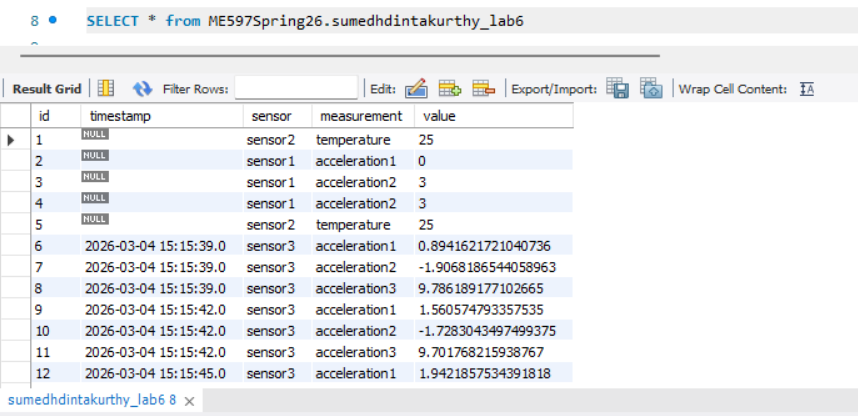
  ---

2.	Place the modified code below

In [ ]:
# Paste your code below.
#

import datetime

import time

import random

import pymysql.cursors



import board

import busio

import adafruit_adxl34x



import os

import glob



# -----------------------------

# MySQL Credentials

# -----------------------------

HOST = 'mepotrb16.ecn.purdue.edu'

PORT = 3306

USER = 'sumedhdintakurthy'

PASSWORD = 'Abcd1234!'

DB = 'ME597Spring26'

TABLE = 'sumedhdintakurthy_lab6'



# -----------------------------

# MySQL Connection

# -----------------------------

connection = pymysql.connect(host=HOST, user=USER, password=PASSWORD, db=DB, port=PORT)

cursor = connection.cursor()



# -----------------------------

# ADXL345 Setup

# -----------------------------

i2c = busio.I2C(board.SCL, board.SDA)

acc = adafruit_adxl34x.ADXL345(i2c)



# -----------------------------

# DS18B20 Temperature Setup

# -----------------------------

os.system('modprobe w1-gpio')

os.system('modprobe w1-therm')



base_dir = '/sys/bus/w1/devices/'

device_folder = glob.glob(base_dir + '28*')[0]

device_file = device_folder + '/w1_slave'





def read_temp_raw():

    f = open(device_file, 'r')

    lines = f.readlines()

    f.close()

    return lines





def read_temp():

    lines = read_temp_raw()



    while lines[0].strip()[-3:] != 'YES':

        time.sleep(0.2)

        lines = read_temp_raw()



    equals_pos = lines[1].find('t=')



    if equals_pos != -1:

        temp_string = lines[1][equals_pos+2:]

        temp_c = float(temp_string) / 1000.0

        return temp_c





# -----------------------------

# Data Collection Settings

# -----------------------------

duration = 120       # Total collection time (seconds)

Ts = 3               # Sampling period (seconds)



start_time = time.time()



while time.time() - start_time < duration:



    timestamp = datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')



    # -----------------------------

    # ADXL345 Accelerometer

    # -----------------------------

    x_acc, y_acc, z_acc = acc.acceleration



    print(f"ADXL345: Xacc={x_acc} m/s^2")

    print(f"ADXL345: Yacc={y_acc} m/s^2")

    print(f"ADXL345: Zacc={z_acc} m/s^2")



    query1 = f"INSERT INTO {TABLE} (timestamp,sensor,measurement,value) VALUES ('{timestamp}','ADXL345','Xacc','{x_acc}')"

    query2 = f"INSERT INTO {TABLE} (timestamp,sensor,measurement,value) VALUES ('{timestamp}','ADXL345','Yacc','{y_acc}')"

    query3 = f"INSERT INTO {TABLE} (timestamp,sensor,measurement,value) VALUES ('{timestamp}','ADXL345','Zacc','{z_acc}')"



    cursor.execute(query1)

    cursor.execute(query2)

    cursor.execute(query3)



    # -----------------------------

    # DS18B20 Temperature

    # -----------------------------

    temperature = read_temp()



    print(f"DS18B20: Temp={temperature} C")



    query4 = f"INSERT INTO {TABLE} (timestamp,sensor,measurement,value) VALUES ('{timestamp}','DS18B20','Temp','{temperature}')"



    cursor.execute(query4)



    # -----------------------------

    # Virtual Humidity Sensor

    # -----------------------------

    humidity = random.uniform(40, 70)



    print(f"Virtual: Humd={humidity} RH%")



    query5 = f"INSERT INTO {TABLE} (timestamp,sensor,measurement,value) VALUES ('{timestamp}','Virtual','Humd','{humidity}')"



    cursor.execute(query5)



    # Commit to database

    connection.commit()



    print("==INSERT QUERIES DONE==\n")



    # Sampling delay

    time.sleep(Ts)



connection.close()



print("==Program DONE==")



#

## Lab6 Summary and Deliverables

Answer the following questions for your achievements




### Q1. Please summarize Lab6.

---

Write down A1 here.
Lab 6 was us learning how we can directly input the data from the sensors into a table in SQL
---


### Q2. What skills did you have to develop to accomplish this project?

---

Write down A2 here.
SQL
---

### Q3. What aspects of this project were the most beneficial for your learning?

---

Write down A3 here.
Integrating SQL and sensor data as we do not have to deal with csv files anymore
---

### Q4. What challenges did you encounter in completing the project?

---

Write down A4 here.
NA
---

### Q5. How did you overcome the challenges or remedy the problems encountered?

---

Write down A5 here.
NA
---

<br></br>

Get back to [Lab Index Page](https://colab.research.google.com/github/purduelamm/purdue_me597_iiot/blob/main/index.ipynb)